<a href="https://colab.research.google.com/github/useDeep/learn_pytorch/blob/main/04_pytorch_custom_datasets.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. Importing Pytorch and settup up device-agnostic code

In [1]:
import torch
from torch import nn

In [2]:
# Setup device-agnostic code
device= "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

## 1. Getting data

In [3]:
import requests
import zipfile
from pathlib import Path

# Setup path to the data folder
data_path= Path("data/")
image_path= data_path / "pizza_steak_sushi"

# If the image folder doesn't exist, download it
if image_path.is_dir():
  print(f"{image_path} already exists. Skipping download.")
else:
  print(f"Creating the dir: {image_path}")
  image_path.mkdir(parents= True,
                   exist_ok= True)

# Download the data
with open(data_path / "pizza_steak_sushi.zip", "wb") as f:
  req= requests.get("https://github.com/mrdbourke/pytorch-deep-learning/raw/refs/heads/main/data/pizza_steak_sushi.zip")
  print(f"Downloading the data")
  f.write(req.content)

# Unzip the file
with zipfile.ZipFile(data_path / "pizza_steak_sushi.zip", "r") as zip_ref:
  print(f"Unzipping the zip file")
  zip_ref.extractall(image_path)

Creating the dir: data/pizza_steak_sushi
Unzipping the zip file


## 2. Data preparation and data exploration

In [4]:
import os
def walk_through_dir(dir_path):
  """Walks through dir_path returning its content"""
  for dirpath, dirnames, filename in os.walk(dir_path):
    print(f"There are {len(dirnames)} directories and {len(filename)} images in '{dirpath}'")

In [5]:
walk_through_dir(image_path)

There are 2 directories and 0 images in 'data/pizza_steak_sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/test'
There are 0 directories and 19 images in 'data/pizza_steak_sushi/test/steak'
There are 0 directories and 25 images in 'data/pizza_steak_sushi/test/pizza'
There are 0 directories and 31 images in 'data/pizza_steak_sushi/test/sushi'
There are 3 directories and 0 images in 'data/pizza_steak_sushi/train'
There are 0 directories and 75 images in 'data/pizza_steak_sushi/train/steak'
There are 0 directories and 78 images in 'data/pizza_steak_sushi/train/pizza'
There are 0 directories and 72 images in 'data/pizza_steak_sushi/train/sushi'


In [6]:
# Setup train and test paths
train_dir= image_path / "train"
test_dir= image_path / "test"

train_dir, test_dir

(PosixPath('data/pizza_steak_sushi/train'),
 PosixPath('data/pizza_steak_sushi/test'))

### 2.1 Visualizing the image

1. Get all of the image paths
2. Pick a random image path using python's random.choice()
3. Get the image class name using `pathlib.Path.parent.stem`
4. Since we're working with images, let's open the image with python's PIL
5. Get the metadata and show the image

Random image path: data/pizza_steak_sushi/train/pizza/2785084.jpg
Image class: pizza
Image height: 366
Image width: 512


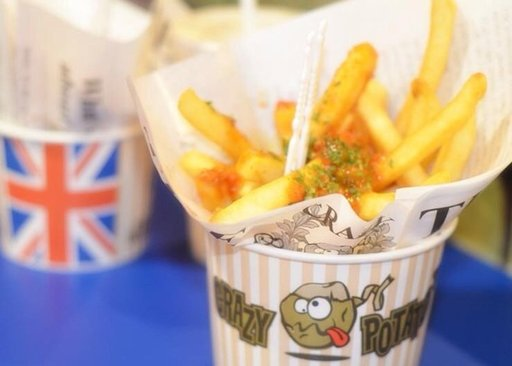

In [7]:
import random
from PIL import Image

# random.seed(77)

# 1. Get all the image paths
image_path_list= list(image_path.glob("*/*/*.jpg"))

# 2. Pick a random image path
random_image_path= random.choice(image_path_list)

# 3. Get the image class (the name of the directory where the image is stored)
image_class= random_image_path.parent.stem

# 4. Open image using PIL
img= Image.open(random_image_path)

# 5. Print metadata
print(f"Random image path: {random_image_path}")
print(f"Image class: {image_class}")
print(f"Image height: {img.height}")
print(f"Image width: {img.width}")
img

In [8]:
type(img)

PIL.JpegImagePlugin.JpegImageFile

(np.float64(-0.5), np.float64(511.5), np.float64(365.5), np.float64(-0.5))

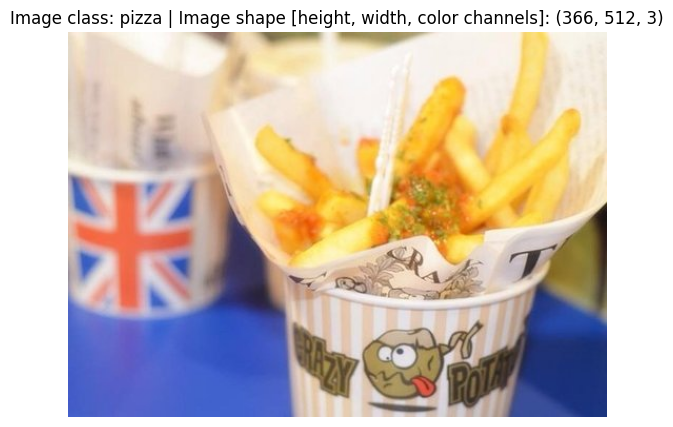

In [9]:
# Visulize using matplotlib
import matplotlib.pyplot as plt
import numpy as np

# Turn the image into array
img_as_array= np.asarray(img)

# Plot the img with matplotlib
plt.figure(figsize=(7, 5))
plt.imshow(img_as_array)
plt.title(f"Image class: {image_class} | Image shape [height, width, color channels]: {img_as_array.shape}")
plt.axis(False)

array([[[234, 221, 202],
        [235, 222, 203],
        [240, 225, 206],
        ...,
        [243, 241, 229],
        [243, 241, 229],
        [243, 241, 229]],

       [[234, 221, 202],
        [235, 222, 203],
        [240, 225, 206],
        ...,
        [243, 241, 229],
        [243, 241, 229],
        [243, 241, 229]],

       [[233, 221, 199],
        [234, 222, 200],
        [239, 224, 205],
        ...,
        [244, 242, 230],
        [243, 241, 229],
        [243, 241, 229]],

       ...,

       [[ 69,  96, 203],
        [ 68,  95, 202],
        [ 68,  95, 202],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]],

       [[ 68,  96, 203],
        [ 68,  96, 203],
        [ 68,  96, 203],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]],

       [[ 68,  96, 203],
        [ 68,  96, 203],
        [ 68,  96, 203],
        ...,
        [ 26,  52, 126],
        [ 26,  53, 124],
        [ 26,  53, 124]]], dtype=uint8)
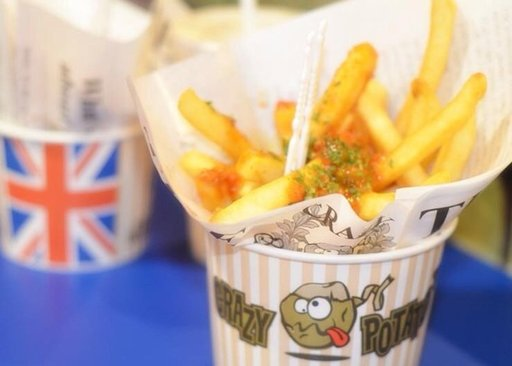

In [10]:
img_as_array

## 3. Transforming data

1. Turn the image data into tensors
2. Turn it into a `torch.utils.data.Dataset` and subsequently a `torch.utils.data.DataLoader`.

In [11]:
import torch
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

### 3.1 Transforming data with `torchvision.transforms`

In [12]:
# Write a transform for images
data_transform= transforms.Compose([    # instead of transforms.Compose, nn.Sequential can also be used
    # Resize the image
    transforms.Resize(size= (64, 64)),
    # Flip the images randomly on the horizontal
    transforms.RandomHorizontalFlip(p= 0.5),
    # Turn the image into tensor
    transforms.ToTensor()   # puts color channel first -> [c, h, w] and converts all pixel values from 0 to 255 to be between 0.0 and 1.0
])

In [13]:
data_transform(img)

tensor([[[0.9490, 0.9686, 0.9255,  ..., 0.9686, 0.9608, 0.9569],
         [0.9294, 0.9608, 0.9216,  ..., 0.9647, 0.9608, 0.9529],
         [0.9216, 0.9490, 0.9216,  ..., 0.9529, 0.9529, 0.9490],
         ...,
         [0.2667, 0.2745, 0.2863,  ..., 0.1020, 0.1059, 0.1098],
         [0.2627, 0.2706, 0.2863,  ..., 0.0980, 0.1020, 0.1059],
         [0.2667, 0.2706, 0.2824,  ..., 0.1020, 0.0980, 0.1020]],

        [[0.8941, 0.9176, 0.8627,  ..., 0.9529, 0.9490, 0.9451],
         [0.8745, 0.9059, 0.8549,  ..., 0.9451, 0.9373, 0.9294],
         [0.8627, 0.8863, 0.8510,  ..., 0.9333, 0.9216, 0.9176],
         ...,
         [0.3608, 0.3725, 0.3765,  ..., 0.1961, 0.1961, 0.1961],
         [0.3647, 0.3686, 0.3765,  ..., 0.1961, 0.2000, 0.2039],
         [0.3725, 0.3765, 0.3765,  ..., 0.2000, 0.2000, 0.2039]],

        [[0.8157, 0.8431, 0.7922,  ..., 0.9098, 0.9020, 0.8980],
         [0.7804, 0.8078, 0.7922,  ..., 0.9020, 0.8941, 0.8824],
         [0.7765, 0.7882, 0.7961,  ..., 0.8902, 0.8745, 0.

In [14]:
data_transform(img).shape

torch.Size([3, 64, 64])

In [15]:
img_as_array.shape

(366, 512, 3)

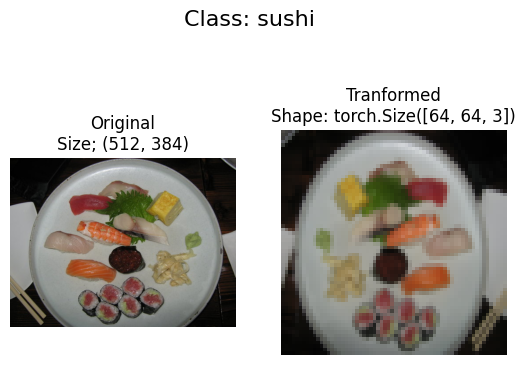

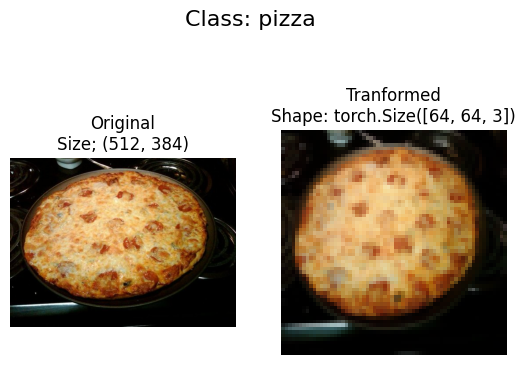

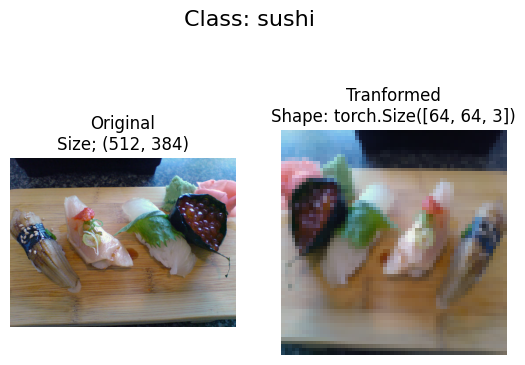

In [16]:
def plot_transformed_images(image_paths: list, transform, n= 3, seed= 77):
  """ Selects random images from a path of images and loads/ transforms them, then plots the original vs transformed version"""
  random_image_paths= random.sample(image_paths, k= n)
  for image_path in random_image_paths:
    with Image.open(image_path) as f:
      fig, ax= plt.subplots(nrows= 1, ncols= 2)
      ax[0].imshow(f)
      ax[0].set_title(f"Original\nSize; {f.size}")
      ax[0].axis(False)

      # Transform and plot target image
      transformed_image= transform(f).permute(1, 2, 0)
      ax[1].imshow(transformed_image)
      ax[1].set_title(f"Tranformed\nShape: {transformed_image.shape}")
      ax[1].axis("off")

      fig.suptitle(f"Class: {image_path.parent.stem}", fontsize= 16)

plot_transformed_images(image_paths= image_path_list,
                        transform= data_transform,
                        n= 3)

## 4. Option 1: Loading image data using `ImageFolder`

Image classification data can be loaded using `torchvision.datasets.ImageFolder`

In [17]:
# Using ImageFolder to create dataset(s)
from torchvision import datasets

train_data= datasets.ImageFolder(root= train_dir,
                                  transform= data_transform,    # transform for the data
                                  target_transform= None)       # transform for the label/ target

test_data= datasets.ImageFolder(root= test_dir,
                                transform= data_transform,
                                target_transform= None)

train_data, test_data

(Dataset ImageFolder
     Number of datapoints: 225
     Root location: data/pizza_steak_sushi/train
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ),
 Dataset ImageFolder
     Number of datapoints: 75
     Root location: data/pizza_steak_sushi/test
     StandardTransform
 Transform: Compose(
                Resize(size=(64, 64), interpolation=bilinear, max_size=None, antialias=True)
                RandomHorizontalFlip(p=0.5)
                ToTensor()
            ))

In [18]:
# Get class names as list
class_names= train_data.classes
class_names

['pizza', 'steak', 'sushi']

In [19]:
class_dict= train_data.class_to_idx
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [20]:
#train_data.targets

In [21]:
train_data.samples[0]

('data/pizza_steak_sushi/train/pizza/1008844.jpg', 0)

In [22]:
# Get index on train_data dataset to get single image and label
train_data[0]

(tensor([[[0.1176, 0.1216, 0.1255,  ..., 0.0980, 0.1020, 0.1137],
          [0.1294, 0.1294, 0.1294,  ..., 0.0980, 0.0980, 0.1059],
          [0.1333, 0.1333, 0.1333,  ..., 0.0941, 0.0980, 0.1020],
          ...,
          [0.1686, 0.1647, 0.1686,  ..., 0.1255, 0.1098, 0.1098],
          [0.1686, 0.1647, 0.1686,  ..., 0.1098, 0.0941, 0.0902],
          [0.1647, 0.1647, 0.1686,  ..., 0.0980, 0.0863, 0.0863]],
 
         [[0.0588, 0.0588, 0.0588,  ..., 0.0745, 0.0706, 0.0745],
          [0.0627, 0.0627, 0.0627,  ..., 0.0745, 0.0706, 0.0745],
          [0.0706, 0.0706, 0.0706,  ..., 0.0745, 0.0745, 0.0706],
          ...,
          [0.2392, 0.2392, 0.2510,  ..., 0.1373, 0.1333, 0.1255],
          [0.2314, 0.2392, 0.2510,  ..., 0.1255, 0.1176, 0.1098],
          [0.2275, 0.2353, 0.2431,  ..., 0.1137, 0.1059, 0.1020]],
 
         [[0.0196, 0.0196, 0.0157,  ..., 0.0902, 0.0902, 0.0941],
          [0.0196, 0.0157, 0.0196,  ..., 0.0902, 0.0863, 0.0902],
          [0.0196, 0.0157, 0.0157,  ...,

In [23]:
img, label= train_data[0][0], train_data[0][1]
label

0

In [24]:
class_names[label]

'pizza'

In [25]:
img.shape

torch.Size([3, 64, 64])

In [26]:
img.dtype

torch.float32

(np.float64(-0.5), np.float64(63.5), np.float64(63.5), np.float64(-0.5))

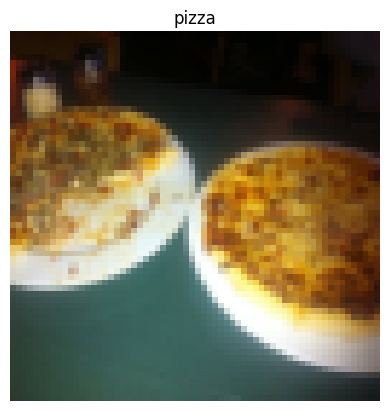

In [27]:
img_permute= img.permute(1, 2, 0)
plt.imshow(img_permute)
plt.title(class_names[label])
plt.axis(False)

### 4.1 Turn loaded images into `DataLoader`

In [28]:
import os
os.cpu_count()

2

In [29]:
from torch.utils.data import DataLoader

BATCH_SIZE= 32
train_dataloader= DataLoader(dataset= train_data,
                             batch_size= BATCH_SIZE,
                             num_workers= os.cpu_count(),
                             shuffle= True
                             )
test_dataloader= DataLoader(dataset= test_data,
                            batch_size= BATCH_SIZE,
                            num_workers= 1,
                            shuffle= True)

train_dataloader, test_dataloader

(<torch.utils.data.dataloader.DataLoader at 0x7bd784f49b50>,
 <torch.utils.data.dataloader.DataLoader at 0x7bd7790f66c0>)

In [30]:
len(train_dataloader), len(test_dataloader)

(8, 3)

In [31]:
225/ 32

7.03125

In [32]:
img, label= next(iter(train_dataloader))

img.shape, label.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 5. Option 2: Loading Image data with custom `Dataset`

In [33]:
import os
import pathlib
from PIL import Image
from torch.utils.data import Dataset
from torchvision import transforms
from typing import Tuple, Dict, List

In [34]:
# Instance of torchvision.datasets.ImageFolder()
train_data.classes, train_data.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.1 Creating a helper function to get class names

1. Get the class names using `os.scandir()` to traverse a target directory (ideally the directory is in standard image classification format).
2. Raise an error if the class names aren't found (if this happens, there might be something wrong with the directory structure).
3. Turn the class names into a dict and a list and return them.

In [35]:
# Setup path for target directory
target_directory= train_dir

# Get the class names from the target directory
class_names_found= sorted(entry.name for entry in list(os.scandir(target_directory)))
class_names_found

['pizza', 'steak', 'sushi']

In [36]:
list(os.scandir(target_directory))

[<DirEntry 'steak'>, <DirEntry 'pizza'>, <DirEntry 'sushi'>]

In [37]:
def find_classes(directory: str) -> Tuple[List[str], Dict[str, int]]:
  """Finds the class folder names in the target directory."""
  # 1. Get the class names by scanning the target directory
  classes= sorted(entry.name for entry in os.scandir(directory) if entry.is_dir())

  # 2. Raise an error if class names could not be found
  if not classes:
    raise FileNotFoundError(f"Couldn't find any classes in {directory}... Please check the file structure")

  # 3. Crete a dictionary of index labels
  class_to_idx= {class_name: i for i, class_name in enumerate(classes)}

  return classes, class_to_idx

In [38]:
find_classes(target_directory)

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.2 Create a custom `Dataset` to replicate `ImageFolder`

To create a custom dataset:
1. Subclass `torch.utils.data.Dataset`
2. Init the subclass with a target directory (the directory that has the data) as well as a transform if we'd like to transform the data.
3. Create several attributes:
    - paths - paths of the data (images here)
    - transform - the transform that would be used
    - classes - a list of the target classes
    - class_to_idx - a dict of the target classes mapped to integer labels
4. Create a function to `load_images()`, this function will open an image
5. Overwrite the `__len__` method to return the lenght of the dataset (optional)
6. Overwrite the `__getitem__()` method to return a given sample when passed an index

In [39]:
# 0. Write a custom dataset class
from torch.utils.data import Dataset

# 1. Subclass torch.utils.data.Dataset
class ImageFolderCustom(Dataset):
  # 2. Initialize the custom dataset
  def __init__(self, targ_dir: str, transform= None):
    # 3. Create class attributes
    # Get all image paths
    self.paths= list(pathlib.Path(targ_dir).glob("*/*.jpg"))
    # Setup transforms
    self.transform= transform
    # Create classes and class_to_idx attributes
    self.classes, self.class_to_idx= find_classes(targ_dir)

  # 4. Create a function to load_images()
  def load_images(self, index: int) -> Image.Image:
    "Open an image via a path and return it."
    image_path= self.paths[index]
    return Image.open(image_path)

  # 5. Overwrite __len__()
  def __len__(self) -> int:
    "Returns the total number of samples"
    return len(self.paths)

  # 6. Overwrite __getitem__() method to return a particular sample
  def __getitem__(self, index: int) -> Tuple[torch.Tensor, int]:
    "Returns one sample of data and it's label -> (X, y)"
    img= self.load_images(index)
    class_name= self.paths[index].parent.name
    class_idx= self.class_to_idx[class_name]

    # Transform (if necessary)
    if self.transform:
      return self.transform(img), class_idx
    else:
      return img, class_idx

In [40]:
# Create a transform
from torchvision import transforms

train_transforms= transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.RandomHorizontalFlip(p= 0.5),
    transforms.ToTensor()
])

test_transforms= transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.ToTensor()
])

In [41]:
train_data_custom= ImageFolderCustom(targ_dir= train_dir, transform= train_transforms)

test_data_custom= ImageFolderCustom(targ_dir= test_dir, transform= test_transforms)

train_data_custom, test_data_custom

(<__main__.ImageFolderCustom at 0x7bd778d81fa0>,
 <__main__.ImageFolderCustom at 0x7bd778d35940>)

In [42]:
len(train_data_custom), len(test_data_custom)

(225, 75)

In [43]:
train_data_custom.classes, train_data_custom.class_to_idx

(['pizza', 'steak', 'sushi'], {'pizza': 0, 'steak': 1, 'sushi': 2})

### 5.3 Create a function to display random images

In [44]:
# 1. Create a function to take in a dataset
def display_random_images(dataset: torch.utils.data.Dataset,
                          classes: List[str]= None,
                          n: int= 10,
                          display_shape: bool= True,
                          seed: int= None):
  # 2. Adjust display if n is too high
  if n> 10:
    n= 10
    display_shape= False
    print("For display purposes, n shouldn't be larger than 10, setting to 10 and removing shape display")

  # 3. Set the seed
  if seed:
    random.seed(seed)

  # 4. Get random sample indices
  random_sample_idx= random.sample(range(len(dataset)), k= n)

  # 5. Setup the plot
  plt.figure(figsize= (16, 8))

  # 6. Loop thorough the random indices and plot the images
  for i, targ_sample in enumerate(random_sample_idx):
    targ_img, targ_label= dataset[targ_sample][0], dataset[targ_sample][1]

    # 7. Adjust tensor dimensions
    targ_img_adjust= targ_img.permute(1, 2, 0)

    # Plot adjusted samples
    plt.subplot(1, n, i+1)
    plt.imshow(targ_img_adjust)
    plt.axis(False)
    if classes:
      title= f"Class: {classes[targ_label]}"
      if display_shape:
        title= title + f"\nshape: {targ_img_adjust.shape}"
    plt.title(title)

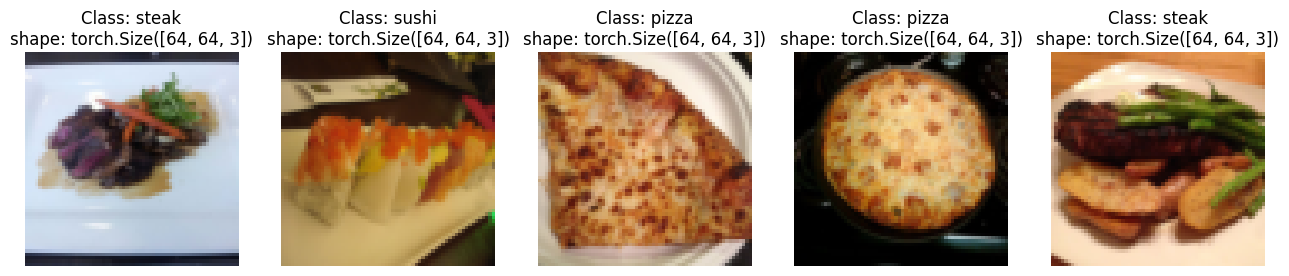

In [45]:
# Display random images from the ImageFolder dataset
display_random_images(dataset= train_data,
                      classes= class_names,
                      n= 5)

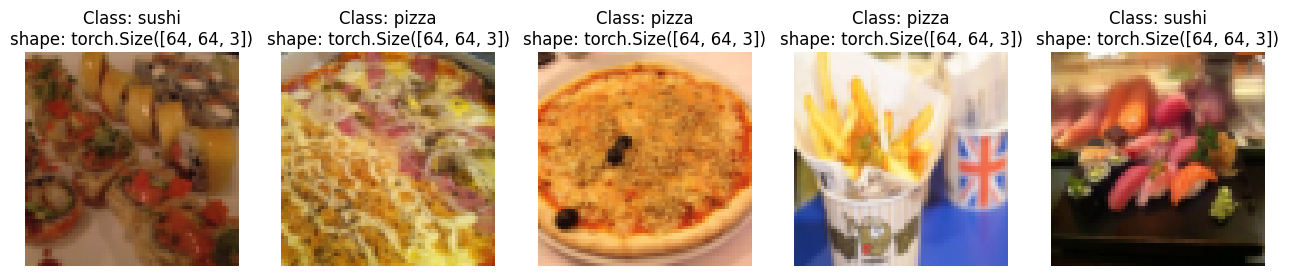

In [46]:
# Display random images from the ImageFolderCustom dataset
display_random_images(dataset= train_data_custom,
                      classes= train_data_custom.classes,
                      n= 5)

### 5.4 Turn custom loaded images into `Dataloader`

In [47]:
from torch.utils.data import DataLoader

BATCH_SIZE= 32

train_dataloader_custom= DataLoader(dataset= train_data_custom,
                                    batch_size= BATCH_SIZE,
                                    num_workers= os.cpu_count(),
                                    shuffle= True)

test_dataloder_custom= DataLoader(dataset= test_data_custom,
                                  batch_size= BATCH_SIZE,
                                  num_workers= 1,
                                  shuffle= False)

train_dataloader_custom, test_dataloder_custom

(<torch.utils.data.dataloader.DataLoader at 0x7bd778070080>,
 <torch.utils.data.dataloader.DataLoader at 0x7bd778d81bb0>)

In [48]:
img_custom, label_custom= next(iter(train_dataloader_custom))

img_custom.shape, label_custom.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

## 6. Other forms of transforms (data augmentation)

In [49]:
#  Working with trivialaugment
from torchvision import transforms

train_transform= transforms.Compose([
    transforms.Resize(size= (224, 224)),
    transforms.TrivialAugmentWide(num_magnitude_bins= 31),
    transforms.ToTensor()
])

test_transform= transforms.Compose([
    transforms.Resize(size= (224, 224)),
    transforms.ToTensor()
])

In [50]:
# Get all image paths
image_path_list= list(image_path.glob("*/*/*.jpg"))
image_path_list[: 10]

[PosixPath('data/pizza_steak_sushi/test/steak/1868005.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/894825.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/27415.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/690177.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2117351.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1016217.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1285886.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/2144308.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/354513.jpg'),
 PosixPath('data/pizza_steak_sushi/test/steak/1882831.jpg')]

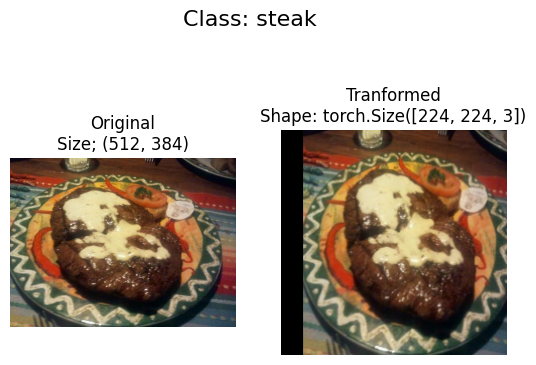

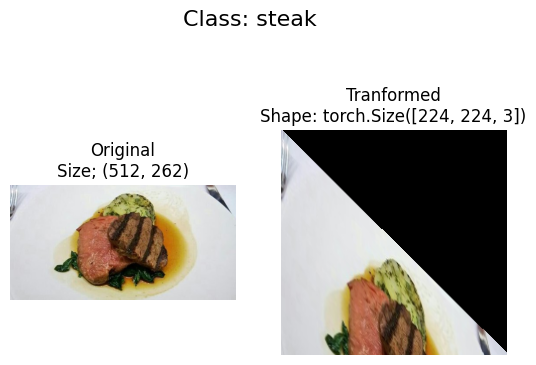

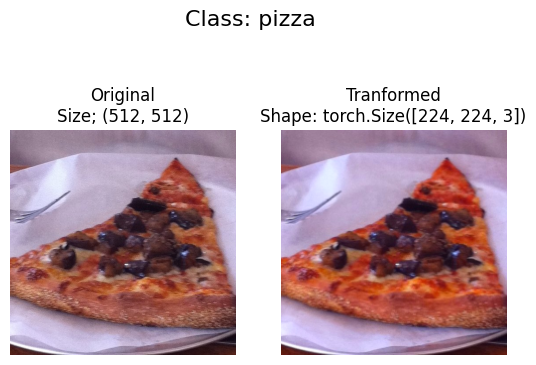

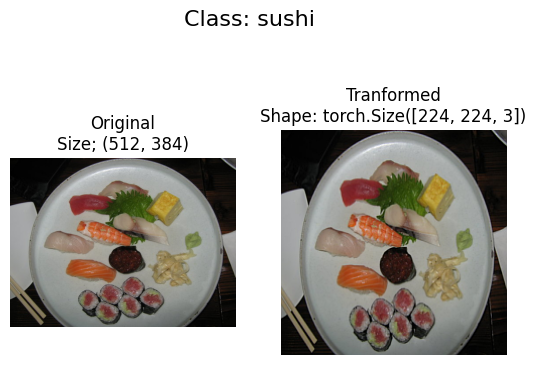

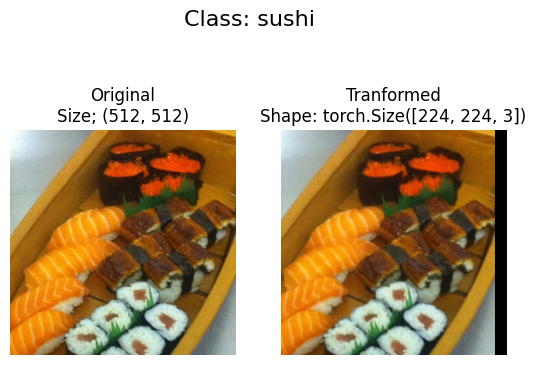

In [51]:
# Plot random transformed images
plot_transformed_images(image_paths= image_path_list,
                        transform= train_transform,
                        n= 5)

## 7. Model 0: TinyVGG without data augmentation

In [52]:
### 7.1 Creating transforms and loading data for Model 0
simple_transform= transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.ToTensor()
])

In [53]:
from torchvision import datasets

train_data_simple= datasets.ImageFolder(root= train_dir,
                                        transform= simple_transform)
test_data_simple= datasets.ImageFolder(root= test_dir,
                                       transform= simple_transform)

In [54]:
# turn dataset into dataloader
import os
from torch.utils.data import DataLoader

BATCH_SIZE= 32
NUM_WORKERS= os.cpu_count()

train_dataloader_simple= DataLoader(dataset= train_data_simple,
                                    batch_size= BATCH_SIZE,
                                    shuffle= True,
                                    num_workers= NUM_WORKERS)
test_dataloader_simple= DataLoader(dataset= test_data_simple,
                                   batch_size= BATCH_SIZE,
                                   num_workers= NUM_WORKERS)

### 7.2 Create TinyVGG model class

In [55]:
class TinyVGG(nn.Module):
  def __init__(self, input_shape: int, hidden_units: int, output_shape: int) -> None:
    super().__init__()
    self.conv_block_1= nn.Sequential(
        nn.Conv2d(in_channels= input_shape,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 0),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2,
                     stride= 2)
    )
    self.conv_block_2= nn.Sequential(
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 0),
        nn.ReLU(),
        nn.Conv2d(in_channels= hidden_units,
                  out_channels= hidden_units,
                  kernel_size= 3,
                  stride= 1,
                  padding= 0),
        nn.ReLU(),
        nn.MaxPool2d(kernel_size= 2,
                     stride= 2)
    )
    self.classifier= nn.Sequential(
        nn.Flatten(),
        nn.Linear(in_features= hidden_units* 13* 13,
                  out_features= output_shape)
    )

  def forward(self, x):
    x= self.conv_block_1(x)
    # print(x.shape)
    x= self.conv_block_2(x)
    # print(x.shape)
    x= self.classifier(x)
    # print(x.shape)
    return x

In [56]:
torch.manual_seed(77)
model_0= TinyVGG(input_shape= 3,
                 hidden_units= 10,
                 output_shape= len(class_names)).to(device)

model_0

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

### 7.3 Try a forward pass on a simple image batch

In [57]:
# Get a single image batch
image_batch, label_batch= next(iter(train_dataloader_simple))
image_batch.shape, label_batch.shape

(torch.Size([32, 3, 64, 64]), torch.Size([32]))

In [58]:
# Try forward pass
model_0(image_batch.to(device))

tensor([[ 0.0103, -0.0465,  0.0203],
        [ 0.0222, -0.0535,  0.0111],
        [ 0.0100, -0.0415,  0.0170],
        [ 0.0152, -0.0435,  0.0144],
        [ 0.0120, -0.0389,  0.0173],
        [ 0.0243, -0.0509,  0.0160],
        [ 0.0211, -0.0440,  0.0142],
        [ 0.0164, -0.0431,  0.0079],
        [ 0.0167, -0.0445,  0.0196],
        [ 0.0106, -0.0428,  0.0177],
        [ 0.0054, -0.0470,  0.0211],
        [ 0.0060, -0.0446,  0.0136],
        [ 0.0120, -0.0443,  0.0156],
        [ 0.0087, -0.0437,  0.0146],
        [ 0.0042, -0.0440,  0.0174],
        [ 0.0144, -0.0463,  0.0238],
        [ 0.0125, -0.0417,  0.0167],
        [ 0.0056, -0.0393,  0.0261],
        [ 0.0173, -0.0431,  0.0177],
        [ 0.0052, -0.0430,  0.0169],
        [ 0.0102, -0.0444,  0.0162],
        [ 0.0081, -0.0421,  0.0125],
        [ 0.0177, -0.0439,  0.0202],
        [ 0.0164, -0.0419,  0.0141],
        [ 0.0128, -0.0457,  0.0265],
        [ 0.0227, -0.0507,  0.0171],
        [ 0.0119, -0.0418,  0.0177],
 

### 7.4 Use `torchinfo` to get an idea of the shapes going through the model

In [59]:
!pip install torchinfo

import torchinfo
from torchinfo import summary

summary(model_0, input_size= [32, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [32, 3]                   --
├─Sequential: 1-1                        [32, 10, 30, 30]          --
│    └─Conv2d: 2-1                       [32, 10, 62, 62]          280
│    └─ReLU: 2-2                         [32, 10, 62, 62]          --
│    └─Conv2d: 2-3                       [32, 10, 60, 60]          910
│    └─ReLU: 2-4                         [32, 10, 60, 60]          --
│    └─MaxPool2d: 2-5                    [32, 10, 30, 30]          --
├─Sequential: 1-2                        [32, 10, 13, 13]          --
│    └─Conv2d: 2-6                       [32, 10, 28, 28]          910
│    └─ReLU: 2-7                         [32, 10, 28, 28]          --
│    └─Conv2d: 2-8                       [32, 10, 26, 26]          910
│    └─ReLU: 2-9                         [32, 10, 26, 26]          --
│    └─MaxPool2d: 2-10                   [32, 10, 13, 13]          --
├─Sequentia

In [60]:
summary(model_0, input_size= [1, 3, 64, 64])

Layer (type:depth-idx)                   Output Shape              Param #
TinyVGG                                  [1, 3]                    --
├─Sequential: 1-1                        [1, 10, 30, 30]           --
│    └─Conv2d: 2-1                       [1, 10, 62, 62]           280
│    └─ReLU: 2-2                         [1, 10, 62, 62]           --
│    └─Conv2d: 2-3                       [1, 10, 60, 60]           910
│    └─ReLU: 2-4                         [1, 10, 60, 60]           --
│    └─MaxPool2d: 2-5                    [1, 10, 30, 30]           --
├─Sequential: 1-2                        [1, 10, 13, 13]           --
│    └─Conv2d: 2-6                       [1, 10, 28, 28]           910
│    └─ReLU: 2-7                         [1, 10, 28, 28]           --
│    └─Conv2d: 2-8                       [1, 10, 26, 26]           910
│    └─ReLU: 2-9                         [1, 10, 26, 26]           --
│    └─MaxPool2d: 2-10                   [1, 10, 13, 13]           --
├─Sequentia

### 7.5 Create train and test loop functions

In [61]:
def train_step(model: torch.nn.Module,
               dataloader: torch.utils.data.DataLoader,
               loss_fn= torch.nn.Module,
               optimizer= torch.optim.Optimizer,
               device= device):

  model.train()

  train_loss, train_acc= 0, 0

  for batch, (X, y) in enumerate(dataloader):
    X, y=  X.to(device), y.to(device)

    y_pred= model(X)
    loss= loss_fn(y_pred, y)
    train_loss+= loss.item()

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    y_pred_class= torch.argmax(torch.softmax(y_pred, dim= 1), dim= 1)
    train_acc+= (y_pred_class == y).sum().item()/ len(y_pred)

  train_loss= train_loss/ len(dataloader)
  train_acc= train_acc/ len(dataloader)

  return train_loss, train_acc

In [62]:
def test_step(model: torch.nn.Module,
              dataloader: torch.utils.data.DataLoader,
              loss_fn: torch.nn.Module,
              device= device):

  model.eval()

  test_loss, test_acc= 0, 0
  with torch.inference_mode():
    for batch, (X, y) in enumerate(dataloader):
      X, y= X.to(device), y.to(device)

      test_pred_logits= model(X)
      loss= loss_fn(test_pred_logits, y)
      test_loss+= loss.item()

      test_pred_labels= test_pred_logits.argmax(dim= 1)
      test_acc+= ((test_pred_labels == y).sum().item()/ len(test_pred_labels))

    test_loss= test_loss / len(dataloader)
    test_acc= test_acc / len(dataloader)

    return test_loss, test_acc

### 7.6 Creating a `train()` function to combine `train_step()` and `test_step()`

In [63]:
from tqdm.auto import tqdm

torch.manual_seed(77)

def train(model: torch.nn.Module,
          train_dataloader: torch.utils.data.DataLoader,
          test_dataloader: torch.utils.data.DataLoader,
          optimizer: torch.optim.Optimizer,
          loss_fn: torch.nn.Module= nn.CrossEntropyLoss(),
          epochs: int= 5,
          device= device):

  # Create empty results dictionary
  results= {"train_loss": [],
            "train_acc": [],
            "test_loss": [],
            "test_acc": []}

  for epoch in tqdm(range(epochs)):
    train_loss, train_acc= train_step(model= model_0,
                                       dataloader= train_dataloader,
                                       loss_fn= loss_fn,
                                       optimizer= optimizer,
                                       device= device)
    test_loss, test_acc= test_step(model= model_0,
                                   dataloader= test_dataloader,
                                   loss_fn= loss_fn,
                                   device= device)

    print(f"Epoch: {epoch} | Train loss: {train_loss:.3f} | Train acc: {train_acc:.3f} | Test loss: {test_loss:.3f} | Test acc: {test_acc:.3f}")

    results["train_loss"].append(train_loss)
    results["train_acc"].append(train_acc)
    results["test_loss"].append(test_loss)
    results["test_acc"].append(test_acc)

  return results

In [81]:
loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params= model_0.parameters(),
                           lr= 0.001)

### 7.7 Train and evaluate model_0

In [82]:
EPOCHS= 5

from timeit import default_timer as timer

start_time= timer()

model_0_results= train(model= model_0,
                       train_dataloader= train_dataloader_simple,
                       test_dataloader= test_dataloader_simple,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs= EPOCHS,
                       device= device)
end_time= timer()
print(f"Total training time: {end_time - start_time:.2f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.097 | Train acc: 0.305 | Test loss: 1.110 | Test acc: 0.260
Epoch: 1 | Train loss: 1.095 | Train acc: 0.426 | Test loss: 1.110 | Test acc: 0.260
Epoch: 2 | Train loss: 1.095 | Train acc: 0.426 | Test loss: 1.111 | Test acc: 0.260
Epoch: 3 | Train loss: 1.097 | Train acc: 0.305 | Test loss: 1.112 | Test acc: 0.260
Epoch: 4 | Train loss: 1.097 | Train acc: 0.305 | Test loss: 1.112 | Test acc: 0.260
Total training time: 11.34 seconds


### 7.8 Plot the loss curves of Model 0

In [83]:
model_0_results

{'train_loss': [1.097321256995201,
  1.0950092822313309,
  1.0947642922401428,
  1.0969412624835968,
  1.0967841148376465],
 'train_acc': [0.3046875, 0.42578125, 0.42578125, 0.3046875, 0.3046875],
 'test_loss': [1.1098262071609497,
  1.1104472080866497,
  1.1109994649887085,
  1.1116504271825154,
  1.1124016443888347],
 'test_acc': [0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667,
  0.2604166666666667]}

In [84]:
def plot_loss_curves(results: Dict[str, List[float]]):
  """Plots training curves of a results dictionary"""
  loss= results["train_loss"]
  test_loss= results["test_loss"]

  accuracy= results["train_acc"]
  test_accuracy= results["test_acc"]

  epochs= range(len(results["train_loss"]))

  plt.figure(figsize= (15, 7))

  plt.subplot(1, 2, 1)
  plt.plot(epochs, loss, label= "train_loss")
  plt.plot(epochs, test_loss, label= "test_loss")
  plt.title("Loss")
  plt.xlabel("Epochs")
  plt.legend()

  plt.subplot(1, 2, 2)
  plt.plot(epochs, accuracy, label= "train_acc")
  plt.plot(epochs, test_accuracy, label= "test_acc")
  plt.title("Accuracy")
  plt.xlabel("Epochs")
  plt.legend()

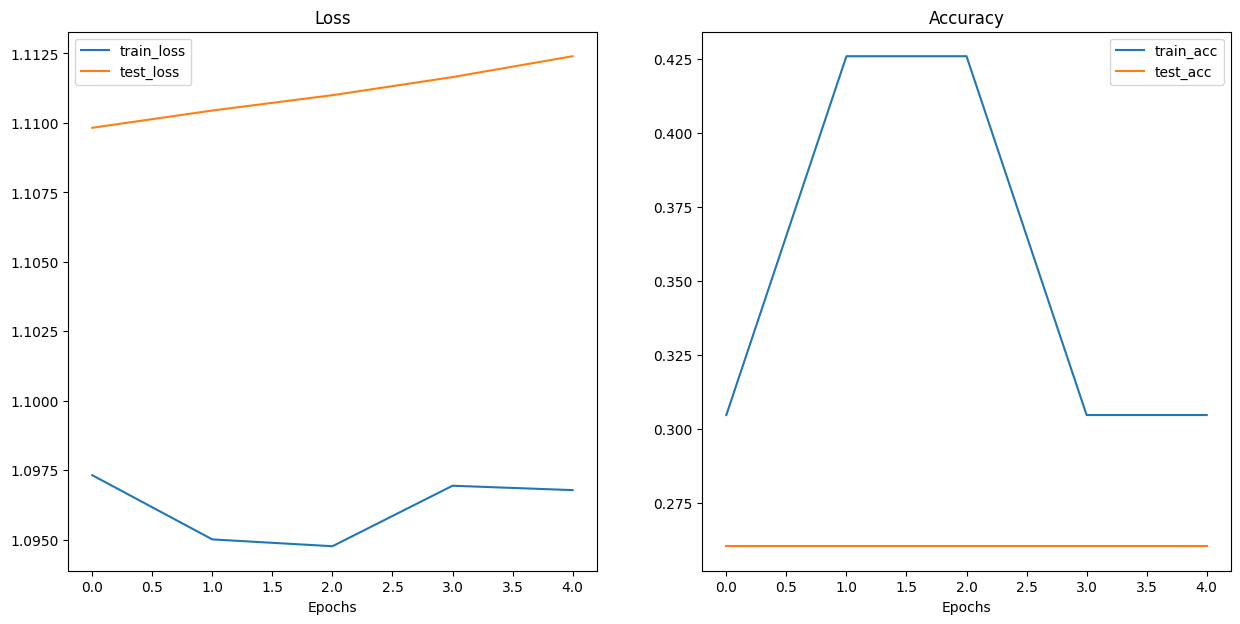

In [85]:
plot_loss_curves(model_0_results)

## 9. Model 1: TinyVGG with augmentation

In [86]:
# Create training transform with TrivialAugment
train_transform_trivial= transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.TrivialAugmentWide(num_magnitude_bins= 31),   # 31 is the max value
    transforms.ToTensor()
])

test_transform_trivial= transforms.Compose([
    transforms.Resize(size= (64, 64)),
    transforms.ToTensor()
])

### 9.2 Create train and test `Dataset`s and `DataLoader`s

In [87]:
train_data_augmented= datasets.ImageFolder(root= train_dir,
                                         transform= train_transform_trivial)

test_data_simple= datasets.ImageFolder(root= test_dir,
                                        transform= test_transform_trivial)

In [88]:
import os
BATCH_SIZE= 32
NUM_WORKERS= os.cpu_count()

torch.manual_seed(77)

train_dataloader_augmented= DataLoader(dataset= train_data_augmented,
                                       batch_size= BATCH_SIZE,
                                       shuffle= True,
                                       num_workers= NUM_WORKERS)

test_dataloader_simple= DataLoader(dataset= test_data_simple,
                                   batch_size= BATCH_SIZE,
                                   shuffle= False,
                                   num_workers= NUM_WORKERS)

### 9.3 Construct and train model_1

(using the same model architecture and only changing the dataset to augmented one)

In [89]:
torch.manual_seed(77)

model_1= TinyVGG(input_shape=3,
                 hidden_units= 10,
                 output_shape= len(train_data_augmented.classes)).to(device)

model_1

TinyVGG(
  (conv_block_1): Sequential(
    (0): Conv2d(3, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (conv_block_2): Sequential(
    (0): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU()
    (2): Conv2d(10, 10, kernel_size=(3, 3), stride=(1, 1))
    (3): ReLU()
    (4): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=1690, out_features=3, bias=True)
  )
)

In [91]:
torch.manual_seed(77)
torch.cuda.manual_seed(77)

EPOCHS= 5

loss_fn= nn.CrossEntropyLoss()
optimizer= torch.optim.Adam(params= model_1.parameters(),
                            lr= 0.001)

start_time= timer()

model_1_results= train(model= model_1,
                       train_dataloader= train_dataloader_augmented,
                       test_dataloader= test_dataloader_simple,
                       optimizer= optimizer,
                       loss_fn= loss_fn,
                       epochs= EPOCHS,
                       device= device)

end_time= timer()

print(f"Total training time for model_1: {end_time - start_time:.3f} seconds")

  0%|          | 0/5 [00:00<?, ?it/s]

Epoch: 0 | Train loss: 1.094 | Train acc: 0.426 | Test loss: 1.112 | Test acc: 0.260
Epoch: 1 | Train loss: 1.104 | Train acc: 0.305 | Test loss: 1.112 | Test acc: 0.260
Epoch: 2 | Train loss: 1.097 | Train acc: 0.305 | Test loss: 1.112 | Test acc: 0.260
Epoch: 3 | Train loss: 1.097 | Train acc: 0.305 | Test loss: 1.112 | Test acc: 0.260
Epoch: 4 | Train loss: 1.094 | Train acc: 0.426 | Test loss: 1.112 | Test acc: 0.260
Total training time for model_1: 13.073 seconds


### 9.4 Plot the loss and acc curves for model_1

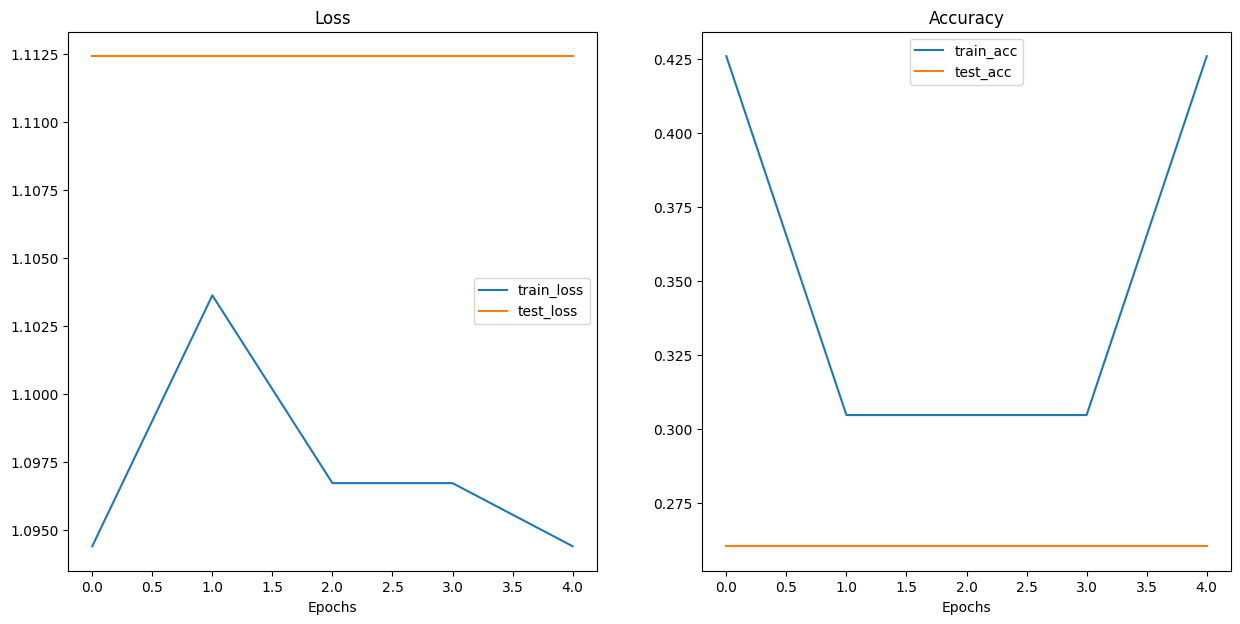

In [93]:
plot_loss_curves(model_1_results)

## 10. Compare different model results

Different ways to do this:
1. Hard coding
2. PyTorch + Tensorboard
3. Weights and Biases
4. MLFlow

In [96]:
import pandas as pd

model_0_df= pd.DataFrame(model_0_results)
model_1_df= pd.DataFrame(model_1_results)

model_0_df

,train_loss,train_acc,test_loss,test_acc
0,1.097321,0.304688,1.109826,0.260417
1,1.095009,0.425781,1.110447,0.260417
2,1.094764,0.425781,1.110999,0.260417
3,1.096941,0.304688,1.111650,0.260417
4,1.096784,0.304688,1.112402,0.260417


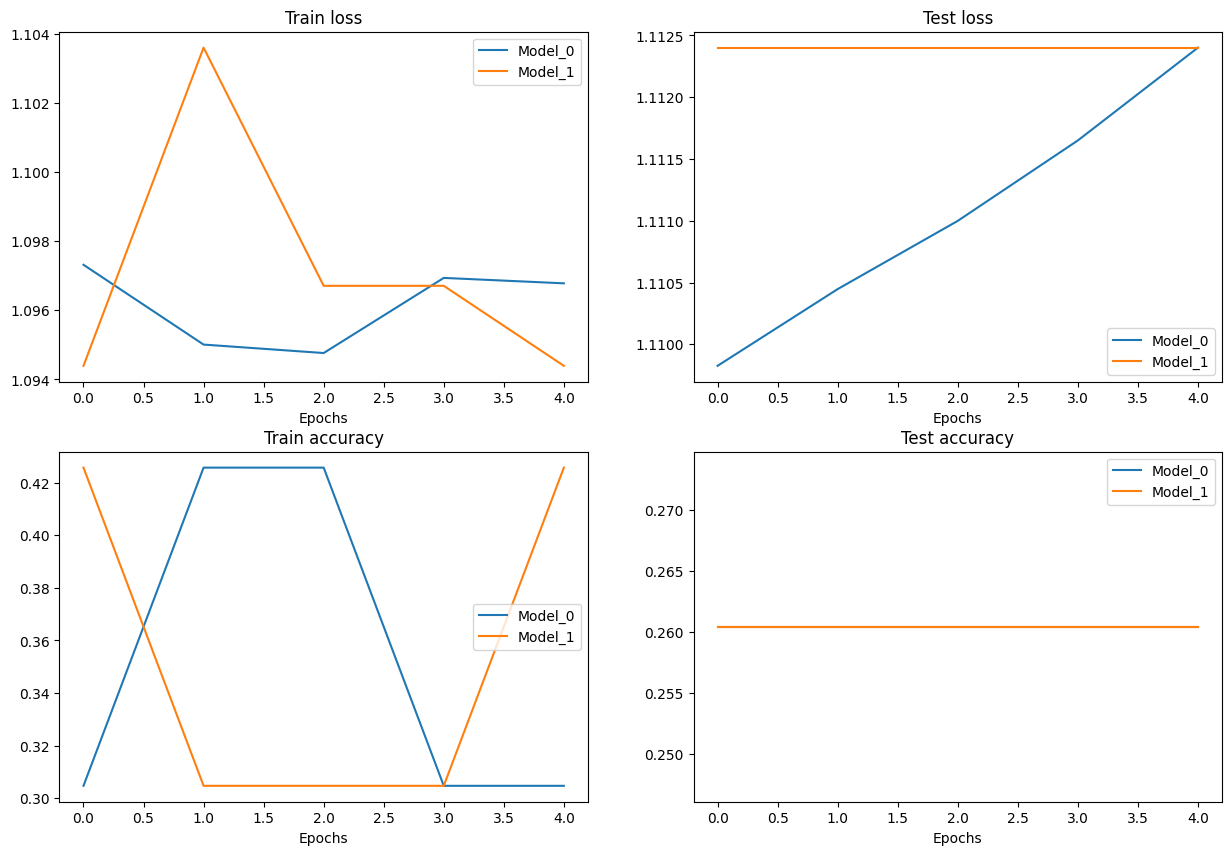

In [104]:
plt.figure(figsize=(15, 10))

epochs= range(len(model_0_df))

plt.subplot(2, 2, 1)
plt.plot(epochs, model_0_df["train_loss"], label= "Model_0")
plt.plot(epochs, model_1_df["train_loss"], label= "Model_1")
plt.title("Train loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 2)
plt.plot(epochs, model_0_df["test_loss"], label= "Model_0")
plt.plot(epochs, model_1_df["test_loss"], label= "Model_1")
plt.title("Test loss")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 3)
plt.plot(epochs, model_0_df["train_acc"], label= "Model_0")
plt.plot(epochs, model_1_df["train_acc"], label= "Model_1")
plt.title("Train accuracy")
plt.xlabel("Epochs")
plt.legend()

plt.subplot(2, 2, 4)
plt.plot(epochs, model_0_df["test_acc"], label= "Model_0")
plt.plot(epochs, model_1_df["test_acc"], label= "Model_1")
plt.title("Test accuracy")
plt.xlabel("Epochs")
plt.legend()

## 11. Making predictions on custom images

Before predicting, make sure the image is
- In tensor form with datatype (torch.float32)
- Of the shape 3 x 64 x 64
- On the right device

In [109]:
# Download a custom image
import requests

custom_image_path= data_path / "sample_pizza.jpeg"

if not custom_image_path.is_file():
  with open(custom_image_path, "wb") as f:
    req= requests.get("https://raw.githubusercontent.com/mrdbourke/pytorch-deep-learning/main/images/04-pizza-dad.jpeg")
    print(f"Dowloaded {custom_image_path}")
    f.write(req.content)
else:
  print(f"{custom_image_path} already exists. Skipping download...")

Dowloaded data/sample_pizza.jpeg


### 11.1 Loading in the custom image

In [112]:
import torchvision

custom_image_uint8= torchvision.io.read_image(str(custom_image_path))
custom_image_uint8

tensor([[[154, 173, 181,  ...,  21,  18,  14],
         [146, 165, 181,  ...,  21,  18,  15],
         [124, 146, 172,  ...,  18,  17,  15],
         ...,
         [ 72,  59,  45,  ..., 152, 150, 148],
         [ 64,  55,  41,  ..., 150, 147, 144],
         [ 64,  60,  46,  ..., 149, 146, 143]],

        [[171, 190, 193,  ...,  22,  19,  15],
         [163, 182, 193,  ...,  22,  19,  16],
         [141, 163, 184,  ...,  19,  18,  16],
         ...,
         [ 55,  42,  28,  ..., 107, 104, 103],
         [ 47,  38,  24,  ..., 108, 104, 102],
         [ 47,  43,  29,  ..., 107, 104, 101]],

        [[119, 138, 147,  ...,  17,  14,  10],
         [111, 130, 145,  ...,  17,  14,  11],
         [ 87, 111, 136,  ...,  14,  13,  11],
         ...,
         [ 35,  22,   8,  ...,  52,  52,  48],
         [ 27,  18,   4,  ...,  50,  49,  44],
         [ 27,  23,   9,  ...,  49,  46,  43]]], dtype=torch.uint8)

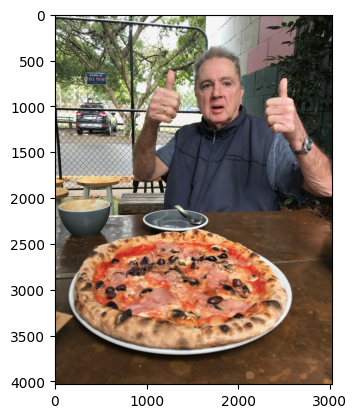

In [113]:
plt.imshow(custom_image_uint8.permute(1, 2, 0))

In [116]:
custom_image_uint8.shape, custom_image_uint8.dtype

(torch.Size([3, 4032, 3024]), torch.uint8)

### 11.2 Making a prediction on custom image with a trained PyTorch model

In [118]:
# Predicting without changing the datatype of unit8 of the sample image
model_1.eval()
with torch.inference_mode():
  model_1(custom_image_uint8.to(device))

RuntimeError: Input type (unsigned char) and bias type (float) should be the same

In [121]:
# Load in the custom image and convert to torch.float32
custom_image= torchvision.io.read_image(str(custom_image_path)).type(torch.float32) / 255   # to get the tensor element values to between 0 and 1

In [122]:
custom_image

tensor([[[0.6039, 0.6784, 0.7098,  ..., 0.0824, 0.0706, 0.0549],
         [0.5725, 0.6471, 0.7098,  ..., 0.0824, 0.0706, 0.0588],
         [0.4863, 0.5725, 0.6745,  ..., 0.0706, 0.0667, 0.0588],
         ...,
         [0.2824, 0.2314, 0.1765,  ..., 0.5961, 0.5882, 0.5804],
         [0.2510, 0.2157, 0.1608,  ..., 0.5882, 0.5765, 0.5647],
         [0.2510, 0.2353, 0.1804,  ..., 0.5843, 0.5725, 0.5608]],

        [[0.6706, 0.7451, 0.7569,  ..., 0.0863, 0.0745, 0.0588],
         [0.6392, 0.7137, 0.7569,  ..., 0.0863, 0.0745, 0.0627],
         [0.5529, 0.6392, 0.7216,  ..., 0.0745, 0.0706, 0.0627],
         ...,
         [0.2157, 0.1647, 0.1098,  ..., 0.4196, 0.4078, 0.4039],
         [0.1843, 0.1490, 0.0941,  ..., 0.4235, 0.4078, 0.4000],
         [0.1843, 0.1686, 0.1137,  ..., 0.4196, 0.4078, 0.3961]],

        [[0.4667, 0.5412, 0.5765,  ..., 0.0667, 0.0549, 0.0392],
         [0.4353, 0.5098, 0.5686,  ..., 0.0667, 0.0549, 0.0431],
         [0.3412, 0.4353, 0.5333,  ..., 0.0549, 0.0510, 0.

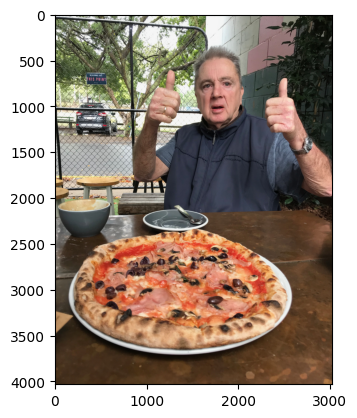

In [125]:
plt.imshow(custom_image.permute(1, 2, 0))

In [123]:
model_1.eval()
with torch.inference_mode():
  model_1(custom_image.to(device))

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x756765 and 1690x3)

In [126]:
# Change the shape of the sample image
custom_image_transform= transforms.Compose([
    transforms.Resize(size= (64, 64))
])

custom_image_transformed= custom_image_transform(custom_image)

custom_image_transformed.shape

torch.Size([3, 64, 64])

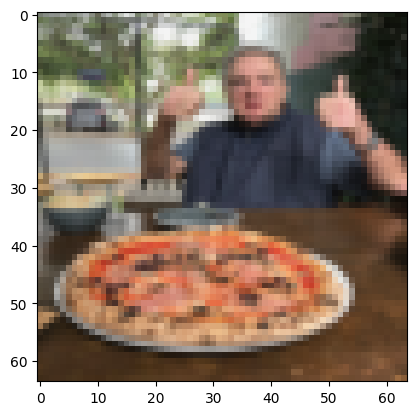

In [128]:
plt.imshow(custom_image_transformed.permute(1, 2, 0))

In [130]:
model_1.eval()
with torch.inference_mode():
  model_1(custom_image_transformed.to(device))    # batch size is not set

RuntimeError: mat1 and mat2 shapes cannot be multiplied (10x169 and 1690x3)

In [133]:
custom_image_transformed.unsqueeze(dim= 0).shape

torch.Size([1, 3, 64, 64])

In [135]:
model_1.eval()
with torch.inference_mode():
  custom_image_pred= model_1(custom_image_transformed.unsqueeze(dim= 0).to(device))
custom_image_pred

tensor([[ 0.0117, -0.0500,  0.0125]])

In [136]:
class_dict

{'pizza': 0, 'steak': 1, 'sushi': 2}

In [137]:
# Convert logits to prediction probabilities
custom_image_pred_probs= torch.softmax(custom_image_pred, dim= 1)
custom_image_pred_probs

tensor([[0.3400, 0.3197, 0.3403]])

In [138]:
# Convert the prediction probabilities to prediction labels
custom_image_pred_labels= torch.argmax(custom_image_pred_probs, dim= 1)
custom_image_pred_labels

tensor([2])

In [139]:
class_names[custom_image_pred_labels]

'sushi'

### 11.3 Putting custom image prediction in a function

In [140]:
def pred_and_plot_image(model: torch.nn.Module,
                        image_path: str,
                        class_names: List[str] = None,
                        transform=None,
                        device: torch.device = device):
    """Makes a prediction on a target image and plots the image with its prediction."""

    # 1. Load in image and convert the tensor values to float32
    target_image = torchvision.io.read_image(str(image_path)).type(torch.float32)

    # 2. Divide the image pixel values by 255 to get them between [0, 1]
    target_image = target_image / 255.

    # 3. Transform if necessary
    if transform:
        target_image = transform(target_image)

    # 4. Make sure the model is on the target device
    model.to(device)

    # 5. Turn on model evaluation mode and inference mode
    model.eval()
    with torch.inference_mode():
        # Add an extra dimension to the image
        target_image = target_image.unsqueeze(dim=0)

        # Make a prediction on image with an extra dimension and send it to the target device
        target_image_pred = model(target_image.to(device))

    # 6. Convert logits -> prediction probabilities (using torch.softmax() for multi-class classification)
    target_image_pred_probs = torch.softmax(target_image_pred, dim=1)

    # 7. Convert prediction probabilities -> prediction labels
    target_image_pred_label = torch.argmax(target_image_pred_probs, dim=1)

    # 8. Plot the image alongside the prediction and prediction probability
    plt.imshow(target_image.squeeze().permute(1, 2, 0)) # make sure it's the right size for matplotlib
    if class_names:
        title = f"Pred: {class_names[target_image_pred_label.cpu()]} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    else:
        title = f"Pred: {target_image_pred_label} | Prob: {target_image_pred_probs.max().cpu():.3f}"
    plt.title(title)
    plt.axis(False);

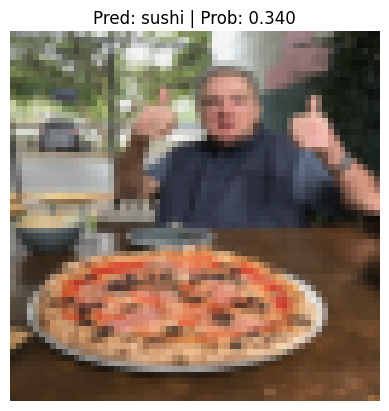

In [141]:
# Pred on our custom image
pred_and_plot_image(model=model_1,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)

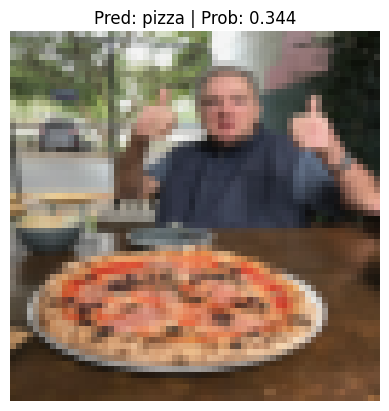

In [142]:
# Pred on our custom image
pred_and_plot_image(model=model_0,
                    image_path=custom_image_path,
                    class_names=class_names,
                    transform=custom_image_transform,
                    device=device)